In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os.path
from datetime import datetime
import matplotlib.pyplot as plt

# Adjust the runtime configuration parameters ("rcParams") of matplotlib (see https://matplotlib.org/stable/users/explain/customizing.html).
from matplotlib import rcParams
# Use latex for all text handling.
#rcParams['text.usetex'] = False

# Exploratory Data Analysis (EDA)

## Table of Contents
- [1. Initial Data Analysis](#1-initial-data-analysis)
- [1.1 Checking the number of NaNs](#11-checking-the-number-of-nans)
- [1.2 Checking the distribution of the data](#12-checking-the-distribution-of-the-data)
- [2. Lagged Auto-Correlation](#2-lagged-auto-correlation)
- [2.1 Linear Regression](#21-linear-regression)
- [2.2 Auto-Correlation](#22-auto-correlation)
- [3. Fourier Transformation (FFT)](#3-fourier-transformation-fft)
- [3.1 A note on wavelets](#31-a-note-on-wavelets)

In [2]:
# Define the string format for the timestamps.
format = '%Y/%m/%d'
# Use ANSI escape sequences for underscores and bold printing.
ansi_escape = '\033'
bu_start = f'{ansi_escape}[1;4;m'
bu_end = f'{ansi_escape}[0m'

In [3]:
path = './data'

In [4]:
file = 'GFS_full_dataset.nc'
gfs_data = xr.open_dataset(os.path.join(path, file))

## **1.** Initial Data Analysis

In [5]:
gfs_data_vars = gfs_data.data_vars
print(gfs_data_vars)

Data variables:
    mean_sea_level_pressure  (time) float64 777kB ...
    zonal_wind               (time) float64 777kB ...
    meridional_wind          (time) float64 777kB ...


In [6]:
# Remove potential leading and trailing NaN values from the data (if they appear in all variables).
nan_mask_all = gfs_data.to_array().isnull().all(dim='variable').values

timesteps_with_values = gfs_data['time'][~nan_mask_all].values

lower_limit = timesteps_with_values.min()
upper_limit = timesteps_with_values.max()

print(f'Data is available from \n{bu_start}lower_limit{bu_end} = {pd.to_datetime(lower_limit).strftime(format)} to \n{bu_start}upper_limit{bu_end} = {pd.to_datetime(upper_limit).strftime(format)}.')

Data is available from 
lower_limit = 2015/01/15 to 
upper_limit = 2026/01/18.


### **1.1** Checking the number of NaNs

In [7]:
for var in gfs_data_vars:
    data = gfs_data[var].sel(time=slice(lower_limit, upper_limit))
    print(f'There are {np.isnan(data).values.sum()} NaN values (out of {data.size} total values) in {bu_start}{var}{bu_end}')

There are 62 NaN values (out of 96526 total values) in mean_sea_level_pressure
There are 62 NaN values (out of 96526 total values) in zonal_wind
There are 62 NaN values (out of 96526 total values) in meridional_wind


### **1.2** Checking the distribution of the data

In [8]:
wind_limits = []
for var in gfs_data.data_vars:
    if 'wind' in var:
        data = gfs_data[var].sel(time=slice(lower_limit, upper_limit))
        wind_limits.append(np.nanmin(data))
        wind_limits.append(np.nanmax(data))

shared_wind_limit = np.ceil(np.abs(wind_limits).max())

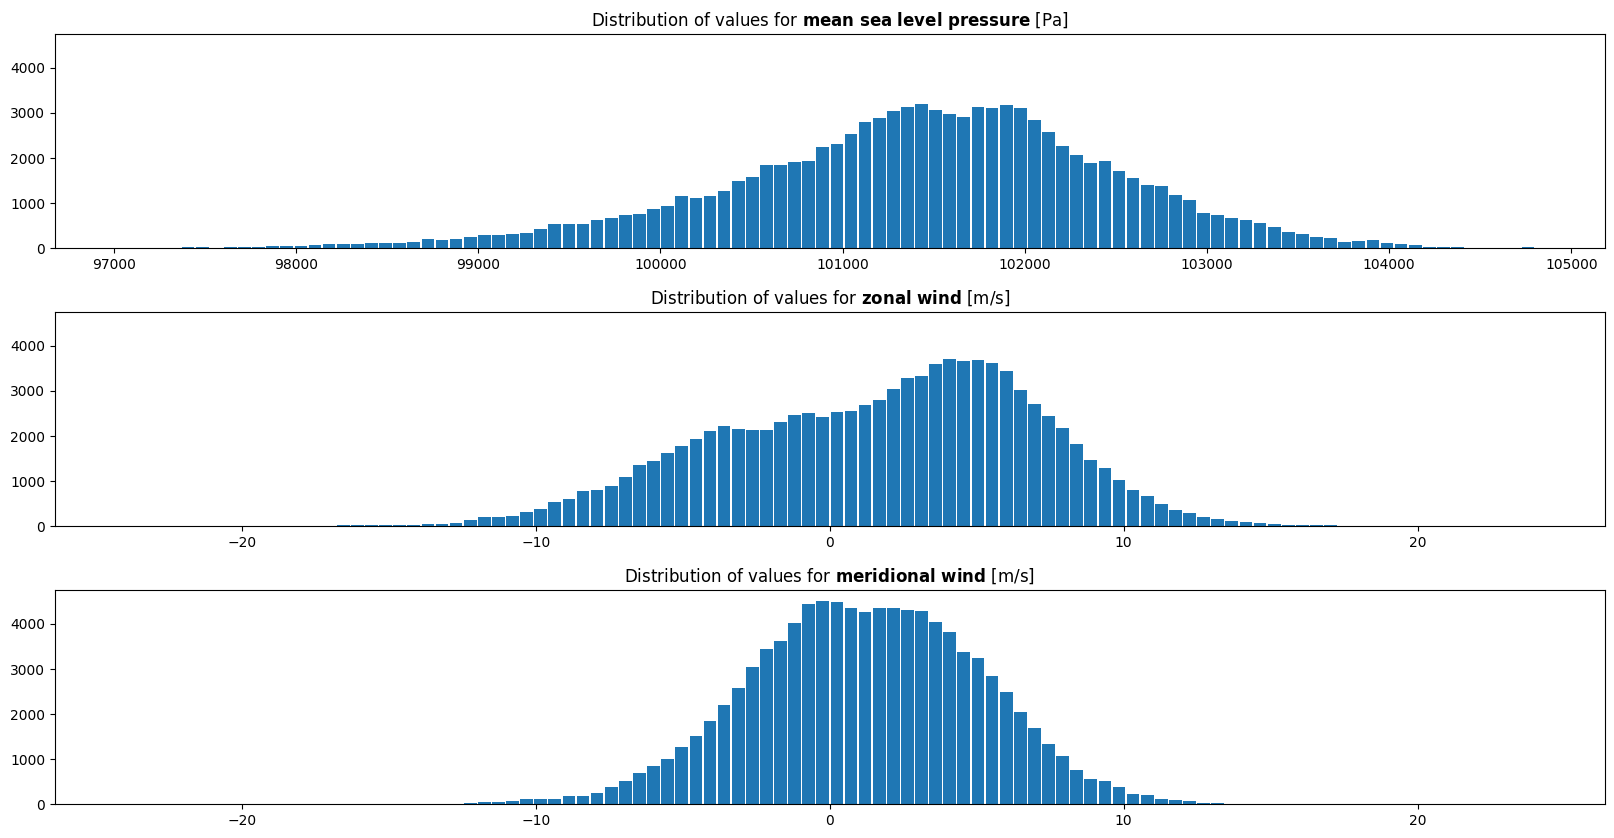

In [9]:
fig, axs = plt.subplots(figsize=(20, 10), nrows=3, sharex=False, sharey=True)
num_bins = 100

for idx, var in enumerate(gfs_data.data_vars):
    data = gfs_data[var].sel(time=slice(lower_limit, upper_limit))

    # Make sure, that the histograms for the wind variables share the same x-axis centered around zero.
    hist_range = (-shared_wind_limit, shared_wind_limit) if 'wind' in var else (np.nanmin(data), np.nanmax(data))
    # Note, that `bin_edges` has length(counts)+1.
    counts, bin_edges = np.histogram(data, bins=num_bins, range=hist_range)

    # Compute the center calculating the mean between the left and right edge of each bin, respectively.
    edge_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Scale the bins in the plot according to their actual width (in relation to the x-axis).
    bin_width = bin_edges[1] - bin_edges[0]

    axs[idx].bar(edge_centers, counts, width=bin_width * 0.9)
    # Note, that '{...}' which should not be interpreted as placeholders in f-strings need to be written as '{{...}}'.
    variable = var.replace('_', r'\ ')
    unit = 'm/s' if 'wind' in var else 'Pa'
    axs[idx].set_title(rf'Distribution of values for $\bf{{{variable}}}$ [{unit}]')

plt.subplots_adjust(hspace=0.3)

## **2.** Lagged Auto-Correlation

The lagged correlation can be used to inform the length of the **context window** for the transformer-based model.

### **2.1** Linear Regression
For a variable $Y$, the linear regression returns a formula $\hat{y}_{i} = \beta x_{i} + \alpha$.

The **total variance** of the variable $Y$ is given $\text{Var}(Y)=\mathbb{E}\left((Y-\mu_{Y})^{2}\right) \propto SS_{yy} = \sum^{n}_{i=1}\left(y_{i}-\bar{y}\right)^{2}$</br>
The **variance explained by the regression** is given by $SSR = \sum^{n}_{i=1}\left(\hat{y}_{i}-\bar{y}\right)^{2}$</br>
The **variance explained by the error of the regression** is given by $SSE = \sum^{n}_{i=1}\left(y_{i}-\hat{y}_{i}\right)^{2}$</br>

The distance between an observation $y_{i}$ and the mean $\bar{y}$ can therefore be written as $y_{i}-\bar{y} = \left(y_{i}-\hat{y}_{i}\right) + \left(\hat{y}_{i}-\bar{y}\right)$ and it can be shown, that $SS_{yy} = SSR + SSE$.</br>
Therefore, the **amount of explained variance** is given by $\displaystyle r^{2} = \frac{SSR}{SS_{yy}} = \frac{\sum^{n}_{i=1}\left(\hat{y}_{i}-\bar{y}\right)^{2}}{\sum^{n}_{i=1}\left(y_{i}-\bar{y}\right)^{2}}$

**Pearson's correlation coefficient** is defined as $r \equiv \text{sgn}\left(\beta\right)\sqrt{r^{2}}$

### **2.2** Auto-Correlation
The auto-correlation is based on the regression of a variable $X$ and a variable $X_{\tau}$ which is a version of $X$ shifted by a lag $\tau$ relative to the original variable $X$.</br>
The lagged values $x_{i,\tau}$ are then estimated by the linear relation $\hat{x}_{i,\tau} = \beta x_{i} + \alpha$.

The parameters $\beta$ and $\alpha$ can be derived from $\frac{\partial}{\partial \beta}\left(SSE\right) = 0$ and $\frac{\partial}{\partial \alpha}\left(SSE\right) = 0$ as:<br>
$\displaystyle \beta = \frac{\sum^{w}_{i=1}\left(x_{i} - \bar{x}\right)\left(x_{i,\tau} - \bar{x}_{\tau}\right)}{\sum^{w}_{i=1}\left(x_{i} - \bar{x}\right)^{2}}$ and $\displaystyle \alpha = \bar{x}_{\tau} - \beta \bar{x}$, respectively.

The **auto-correlcation coefficient** therefore can be written as
$\displaystyle
r \equiv \text{sgn}\left(\beta\right)\sqrt{\frac{SSR}{SS_{x_{\tau}x_{\tau}}}} = \text{sgn}\left(\beta\right)\sqrt{\frac{\sum^{w}_{i=1}\left(\hat{x}_{i,\tau}-\bar{x}_{\tau}\right)^{2}}{\sum^{w}_{i=1}\left(x_{i,\tau}-\bar{x}_{\tau}\right)^{2}}}
$


In [10]:
def linear_regression(x, y):
    x_mean = x.mean()
    y_mean = y.mean()

    # Compute the slope.
    slope = ((x-x_mean) * (y-y_mean)).sum() / ((x-x_mean)**2).sum()
    
    # Compute the offset.
    offset = y_mean - x_mean * slope

    return(slope, offset)

In [11]:
def auto_correlation(input_var, lag):
    numel_in_window = input_var.size - lag

    # `x` is given by the first `numel_in_window` elements in the input.
    x = input_var[:numel_in_window]
    x_tau = input_var[lag:]

    # Make sure to exclude the same values for `x` or `x_tau` by exluding the values that are NaN in either `x` or `x_tau`.
    non_nan_mask = (~np.isnan(x)) & (~np.isnan(x_tau))

    # Return NaN, if there are no actual values in the window (highly unlikely).
    if not non_nan_mask.any():
        return np.nan

    slope, offset = linear_regression(x[non_nan_mask], x_tau[non_nan_mask])

    # Use the parameters of the linear regression to compute the predition `x_tau_hat`. 
    x_tau_hat = slope * x[non_nan_mask] + offset
    x_tau_mean = x_tau[non_nan_mask].mean()

    auto_corr_coeff = np.sign(slope) * np.sqrt(((x_tau_hat - x_tau_mean)**2).sum() / ((x_tau[non_nan_mask] - x_tau_mean)**2).sum())

    return auto_corr_coeff

In [12]:
max_lag_days = 366
max_lag_hours = max_lag_days * 24

lags_in_hours = np.arange(max_lag_hours + 1) 

lagged_corr_coeffs = {var: lags_in_hours * np.nan for var in gfs_data.data_vars}
for var in gfs_data.data_vars:
    data = gfs_data[var].sel(time=slice(lower_limit, upper_limit))

    for idx, lag in enumerate(lags_in_hours):
        lagged_corr_coeffs[var][idx] = auto_correlation(data.values, lag)   


Alternatively, the code below could be used.</br>
Note, that the variant using an FFT (see *Convolution Theorem*) or the standard auto-correlation function (ACF) uses the global mean and variance across the whole time series instead of only considering the values within the given window.

In [13]:
# from statsmodels.tsa.stattools import acf

# # acf computes the values for all lags up to `nlags` efficiently via an FFT while correctly handling NaN values.
# lag_values = acf(data, nlags=max_lag_hours, missing='drop', fft=True)

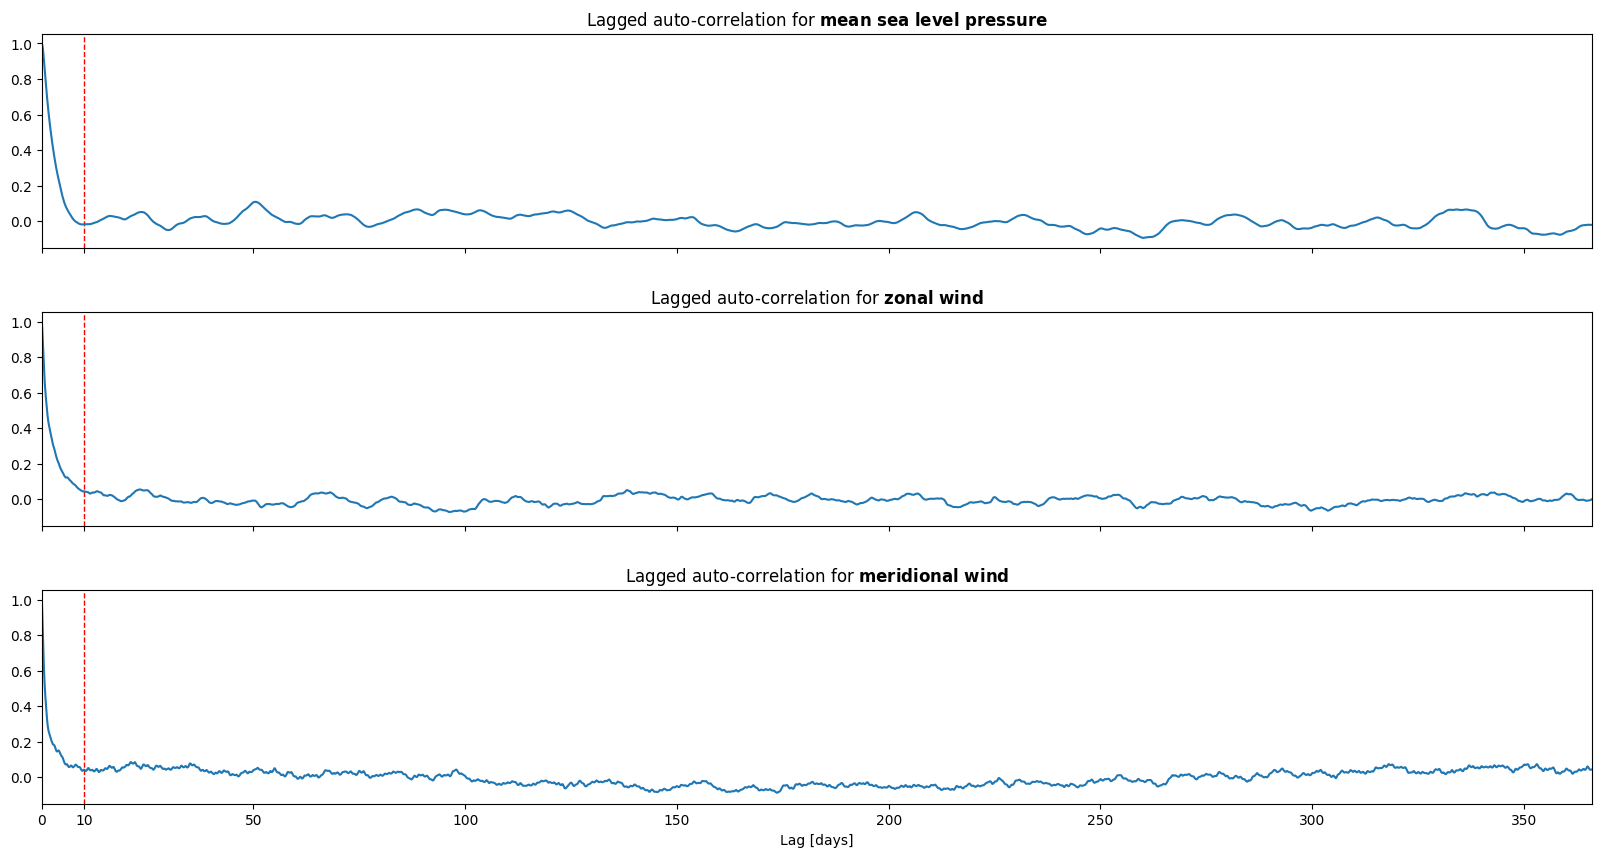

In [14]:
context_limit_days = 10
fig, axs = plt.subplots(figsize=(20, 10), nrows=3, sharex=True, sharey=True)

for idx, var in enumerate(gfs_data.data_vars):
    axs[idx].plot(lags_in_hours / 24, lagged_corr_coeffs[var])
    axs[idx].axvline(context_limit_days, linestyle='--', linewidth=1, color='r', zorder=0)

    # Note, that '{...}' which should not be interpreted as placeholders in f-strings need to be written as '{{...}}'.
    variable = var.replace('_', r'\ ')
    axs[idx].set_title(rf'Lagged auto-correlation for $\bf{{{variable}}}$')
    if idx == (len(gfs_data.data_vars) - 1):
        axs[idx].set_xlabel('Lag [days]')
        xticks = axs[idx].get_xticks()
        axs[idx].set_xticks(np.append(xticks, context_limit_days))
        axs[idx].set_xlim(0, max_lag_days)

plt.subplots_adjust(hspace=0.3)

## **3.** Fourier Transformation (FFT)

Assuming stationarity of the signal, the FFT can be used to inform the intial values for the **positional encoding** of the transformer-based model.

A timeseries $x(t)$ can be written as a Fourier series $\displaystyle x(t) = \sum_{n=-\infty}^{\infty}c_{n}\exp\left(i 2\pi \frac{n}{P}\cdot t\right)$, where $P$ is the fundamental period and $\displaystyle \frac{n}{P}$ is the $n$-th harmonic.</br>
The amplitude $c_{n}$ is a complex number, that defines the amplitude of the sine and cosine portion for a given frequency $\displaystyle f_{n} = \frac{n}{P}$.

The Fourier Transform for this time series is given by $\displaystyle X\left(f_{n}\right) = \int_{-\infty}^{\infty}x(t)\exp(-i 2\pi f_n\cdot t)\ dt$

In the discrete case, the signal is assumed to be sampled in intervals defined by $t_{k} = \Delta k$, with $k=0,1,2,\dots,N-1$, that is, $f_{\text{s}} = \Delta^{-1}$.</br>
The **Nyquist frequency** defines the maximum frequency that can be resolved without aliasing as $f_{\text{Nyquist}} = \frac{f_{\text{s}}}{2}$.</br>
Therefore, the resolvable frequencies are given by $f_{n} = \frac{1}{\Delta}\frac{n}{N}$, für $n=-\frac{N}{2},-\frac{N}{2}+1,\dots,\frac{N}{2}-1$.</br>
*(Note, that negative frequencies are only used for reasons of mathematical simplification, as they do not correspond to meaningful physical entities)*

The discrete Fourier Transform can be written as $\displaystyle X\left(f_{n}\right) = \sum_{k=0}^{N-1}x(t_k)\exp(-i 2\pi f_n\cdot t_k)\ \Delta$.

If the length of the time series does not exactly equal an integer periodic of the fundamental frequency $\displaystyle \frac{1}{P}$, the Fourier transform will result in **spectral leakage**.</br>
This can be avoided by tapering the signal prior to the transformation using a suitable window function (e.g., Hann-window).

In [15]:
# The standard DFT has a complexity of O(N²) in both time and space, if using vectorization with e.g. `np.mehsgrid(...)`.
# Common FFT implementations use divide and conquer (Cooley-Tukey alogrithm) and operate mostly in-place resulting in O(N) space complexity and O(N log N) time complexity.
delta_hours = 1

real_valued_dft = {}

for var in gfs_data_vars:
    data = gfs_data[var].sel(time=slice(lower_limit, upper_limit))

    # Deal with NaN values via linear interpolation.
    data_interp = data.interpolate_na(dim="time", method="linear")

    # Remove the mean to avoid a strong signal at f = 0.
    data_demean = data_interp - data.mean()
    
    # Use a Hanning window to avoid spectral leakage.
    window = np.hanning(data.size)

    # Use a real-valued FFT to further reduce the complexity by disregarding negative frequencies (viable for real-valued signals, since X(-fᵢ) = X*(fᵢ)).
    X_f = np.fft.rfft(data_demean * window)
    frequencies_hours = np.fft.rfftfreq(data.size, d=delta_hours) # Returns f_n = [0, ..., n/2] * 1/n * 1/d, where 1/d = f_s in hours⁻¹.

    real_valued_dft[var] = (X_f, frequencies_hours)

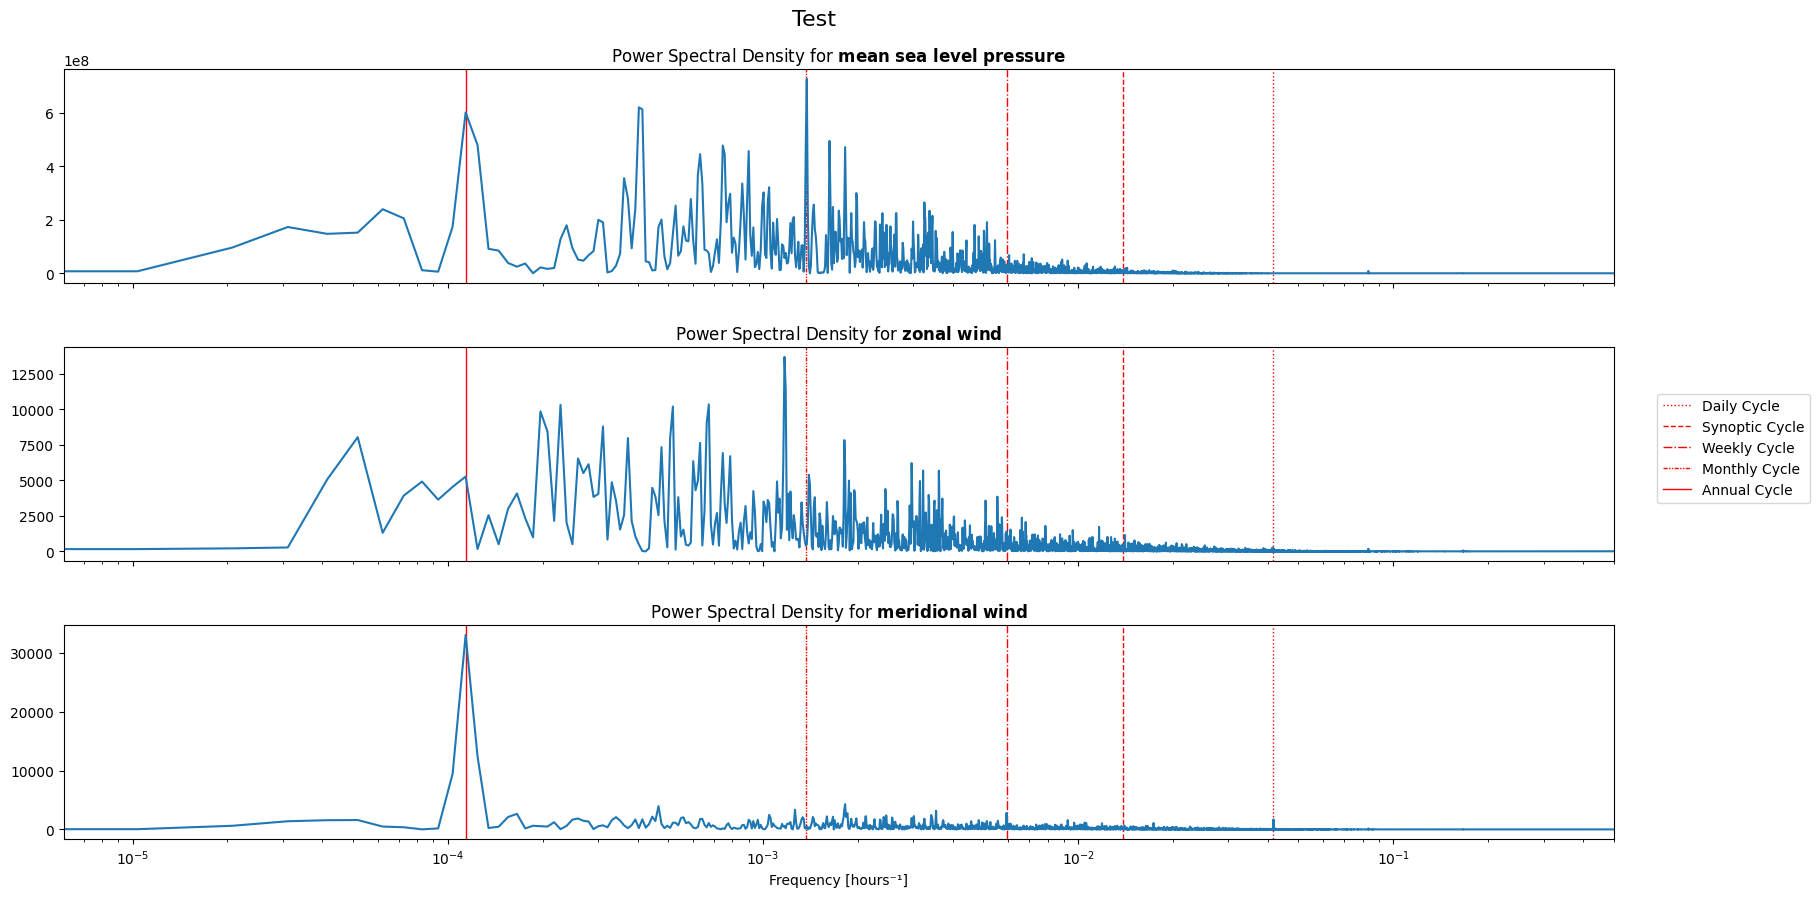

In [ ]:
context_limit_days = 10
fig, axs = plt.subplots(figsize=(20, 10), nrows=3, sharex=True)

for idx, var in enumerate(gfs_data.data_vars):
    X_f, frequencies_hours = real_valued_dft[var]

    # Plot the normalized Power Spectral Density (PSD) given by 1/N * |X_f|² (assuming a rectangular window of length N).
    # Note that the Hanning window applied above has an effect on the variance, that needs to be accounted for here.
    psd = (np.abs(X_f)**2) / (np.hanning(data.size)**2).sum()
    axs[idx].plot(frequencies_hours, psd)

    axs[idx].axvline(1/(24 *   1),         linestyle='dotted',                linewidth=1, color='r', zorder=0, label='Daily Cycle')    
    axs[idx].axvline(1/(24 *   3),         linestyle='dashed',                linewidth=1, color='r', zorder=0, label='Synoptic Cycle')
    axs[idx].axvline(1/(24 *   7),         linestyle='dashdot',               linewidth=1, color='r', zorder=0, label='Weekly Cycle')
    axs[idx].axvline(1/(24 * 365.25 / 12), linestyle=(0, (3, 1, 1, 1, 1, 1)), linewidth=1, color='r', zorder=0, label='Monthly Cycle')
    axs[idx].axvline(1/(24 * 365.25),      linestyle='solid',                 linewidth=1, color='r', zorder=0, label='Annual Cycle')

    # Note, that '{...}' which should not be interpreted as placeholders in f-strings need to be written as '{{...}}'.
    variable = var.replace('_', r'\ ')
    axs[idx].set_title(rf'Power Spectral Density for $\bf{{{variable}}}$')
    axs[idx].set_xscale('log')
    # Only set the the right limit, as setting the left limit to zero will trigger "UserWarning: Attempt to set non-positive xlim".
    axs[idx].set_xlim(right=max(frequencies_hours))

    if idx == (len(gfs_data.data_vars) - 1):
        axs[idx].set_xlabel('Frequency [hours⁻¹]')

fig.legend(*axs[0].get_legend_handles_labels(), loc='center right')

plt.subplots_adjust(hspace=0.3)
plt.show()

### **3.1** A note on wavelets

An **FFT** builds on the assumption, that the signal is stationary and therefore analyze the properties of the global spectrum across the complete sample period.</br>
In contrast, **wavelets** allow to analyze non-stationary signals via local analysis of the frequency specturm, thus allowing to investigate, when which frequency dominates.

It can be assumed, that a transformer-based model is able to pick up potential non-stationarities via the attention mechanism.</br>
Therefore, using the results of the **FFT** to inform the positional encoding of a transformer-based model should be sufficient in the given context.